1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


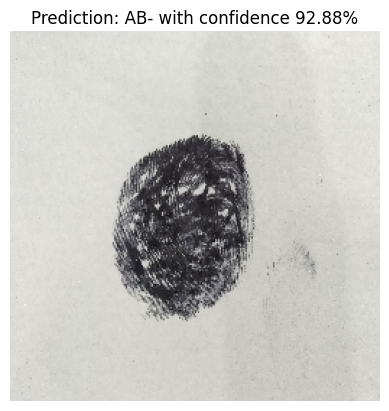

In [ ]:
import os
os.chdir('C:\\Users\\Reddy Y L\\Documents\\Projects\\fingerprint-based-blood-group-detection-main')

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

# Load the model from correct path
model = load_model('test/model_blood_group_detection_resnet.h5')

labels = ['A+', 'A-', 'AB+', 'AB-', 'B+', 'B-', 'O+', 'O-']

# Find and load a sample image
sample_dirs = ['dataset/dataset_blood_group/A+', 'dataset/dataset_blood_group/O+']
img_path = None

for dir_path in sample_dirs:
    if os.path.exists(dir_path):
        images = [f for f in os.listdir(dir_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
        if images:
            img_path = os.path.join(dir_path, images[0])
            break

if img_path:
    img = image.load_img(img_path, target_size=(256, 256))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = x / 255.0
    
    result = model.predict(x)
    predicted_class = np.argmax(result)
    predicted_label = labels[predicted_class]
    confidence = result[0][predicted_class] * 100
    
    plt.figure(figsize=(8, 6))
    plt.imshow(img)  # img is a PIL Image, imshow handles it directly
    plt.axis('off')
    plt.title(f"Prediction: {predicted_label} ({confidence:.2f}% confidence)")
    plt.tight_layout()
    plt.show()
else:
    print("No images found!")